In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
DATASET_PATH = "../dataset/color"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Split validation + test approximately 50/50
total_batches = tf.data.experimental.cardinality(
    validation_test_dataset
).numpy()

test_size = total_batches // 2

test_dataset = validation_test_dataset.take(test_size)
validation_dataset = validation_test_dataset.skip(test_size)

class_names = train_dataset.class_names

print("Number of classes:", len(class_names))

Found 54305 files belonging to 38 classes.
Using 38014 files for training.
Found 54305 files belonging to 38 classes.
Using 16291 files for validation.
Number of classes: 38


In [3]:
normalization_layer = layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

In [4]:
model = models.Sequential([

    # Data augmentation
    data_augmentation,

    # Normalize pixels from 0-255 to 0-1
    normalization_layer,

    # First CNN block
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Second CNN block
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Third CNN block
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Convert feature maps into a vector
    layers.Flatten(),

    # Classification layers
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Output layer - 38 plant disease classes
    layers.Dense(len(class_names), activation="softmax")
])

print("Custom CNN created successfully!")

Custom CNN created successfully!


In [5]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [7]:
import os

os.makedirs("../models", exist_ok=True)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/best_custom_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [8]:
EPOCHS = 15

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/15


c:\Users\Ritik\OneDrive\Desktop\PlantHealth-AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6237 - loss: 1.3439
Epoch 1: val_accuracy improved from None to 0.57299, saving model to ../models/best_custom_cnn.keras

Epoch 1: finished saving model to ../models/best_custom_cnn.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2216s 2s/step - accuracy: 0.6237 - loss: 1.3439 - val_accuracy: 0.5730 - val_loss: 1.6871
Epoch 2/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7785 - loss: 0.7262
Epoch 2: val_accuracy improved from 0.57299 to 0.80790, saving model to ../models/best_custom_cnn.keras

Epoch 2: finished saving model to ../models/best_custom_cnn.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2218s 2s/step - accuracy: 0.7785 - loss: 0.7262 - val_accuracy: 0.8079 - val_loss: 0.6038
Epoch 3/15
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8474 - loss: 0.4787
Epoch 3: val_accuracy did not improve from 0.80790
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2551s 2s/step - accuracy: 0.8474 - loss: 0.4787 - val_accuracy: 0.7505 - val_loss: 0.93

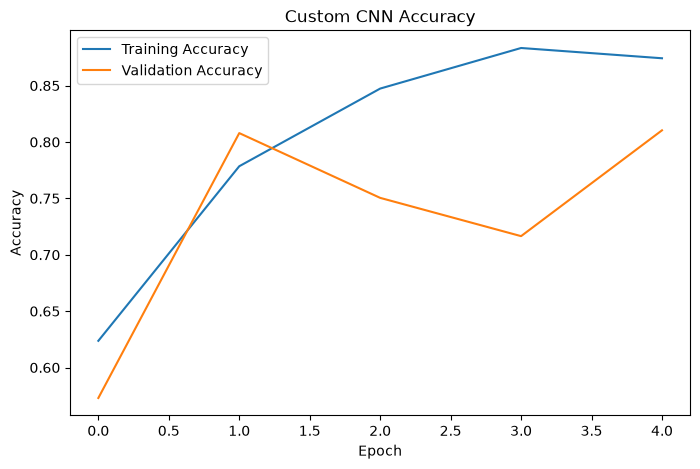

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Accuracy")
plt.legend()

plt.show()

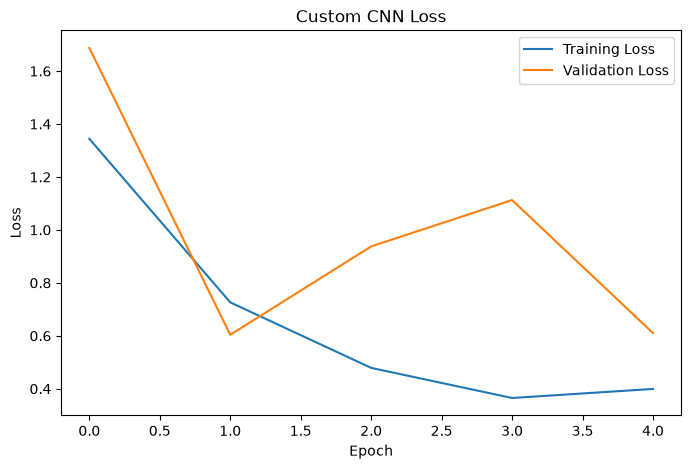

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Loss")
plt.legend()

plt.show()

In [11]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

255/255 ━━━━━━━━━━━━━━━━━━━━ 62s 241ms/step - accuracy: 0.8116 - loss: 0.6029
Test Loss: 0.6029191017150879
Test Accuracy: 0.8116421699523926


In [12]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Get predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed!")

Predictions completed!


In [13]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.7465    0.5464    0.6310        97
                                 Apple___Black_rot     0.8854    0.8586    0.8718        99
                          Apple___Cedar_apple_rust     1.0000    0.1471    0.2564        34
                                   Apple___healthy     0.9259    0.3219    0.4777       233
                               Blueberry___healthy     0.9231    0.9702    0.9461       235
          Cherry_(including_sour)___Powdery_mildew     0.5750    0.9517    0.7169       145
                 Cherry_(including_sour)___healthy     0.9600    0.2124    0.3478       113
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7500    0.5185    0.6131        81
                       Corn_(maize)___Common_rust_     0.9892    0.9293    0.9583       198
               Corn_(maize)___Northern_Leaf_Blight     0.7712    0.8138    0.79

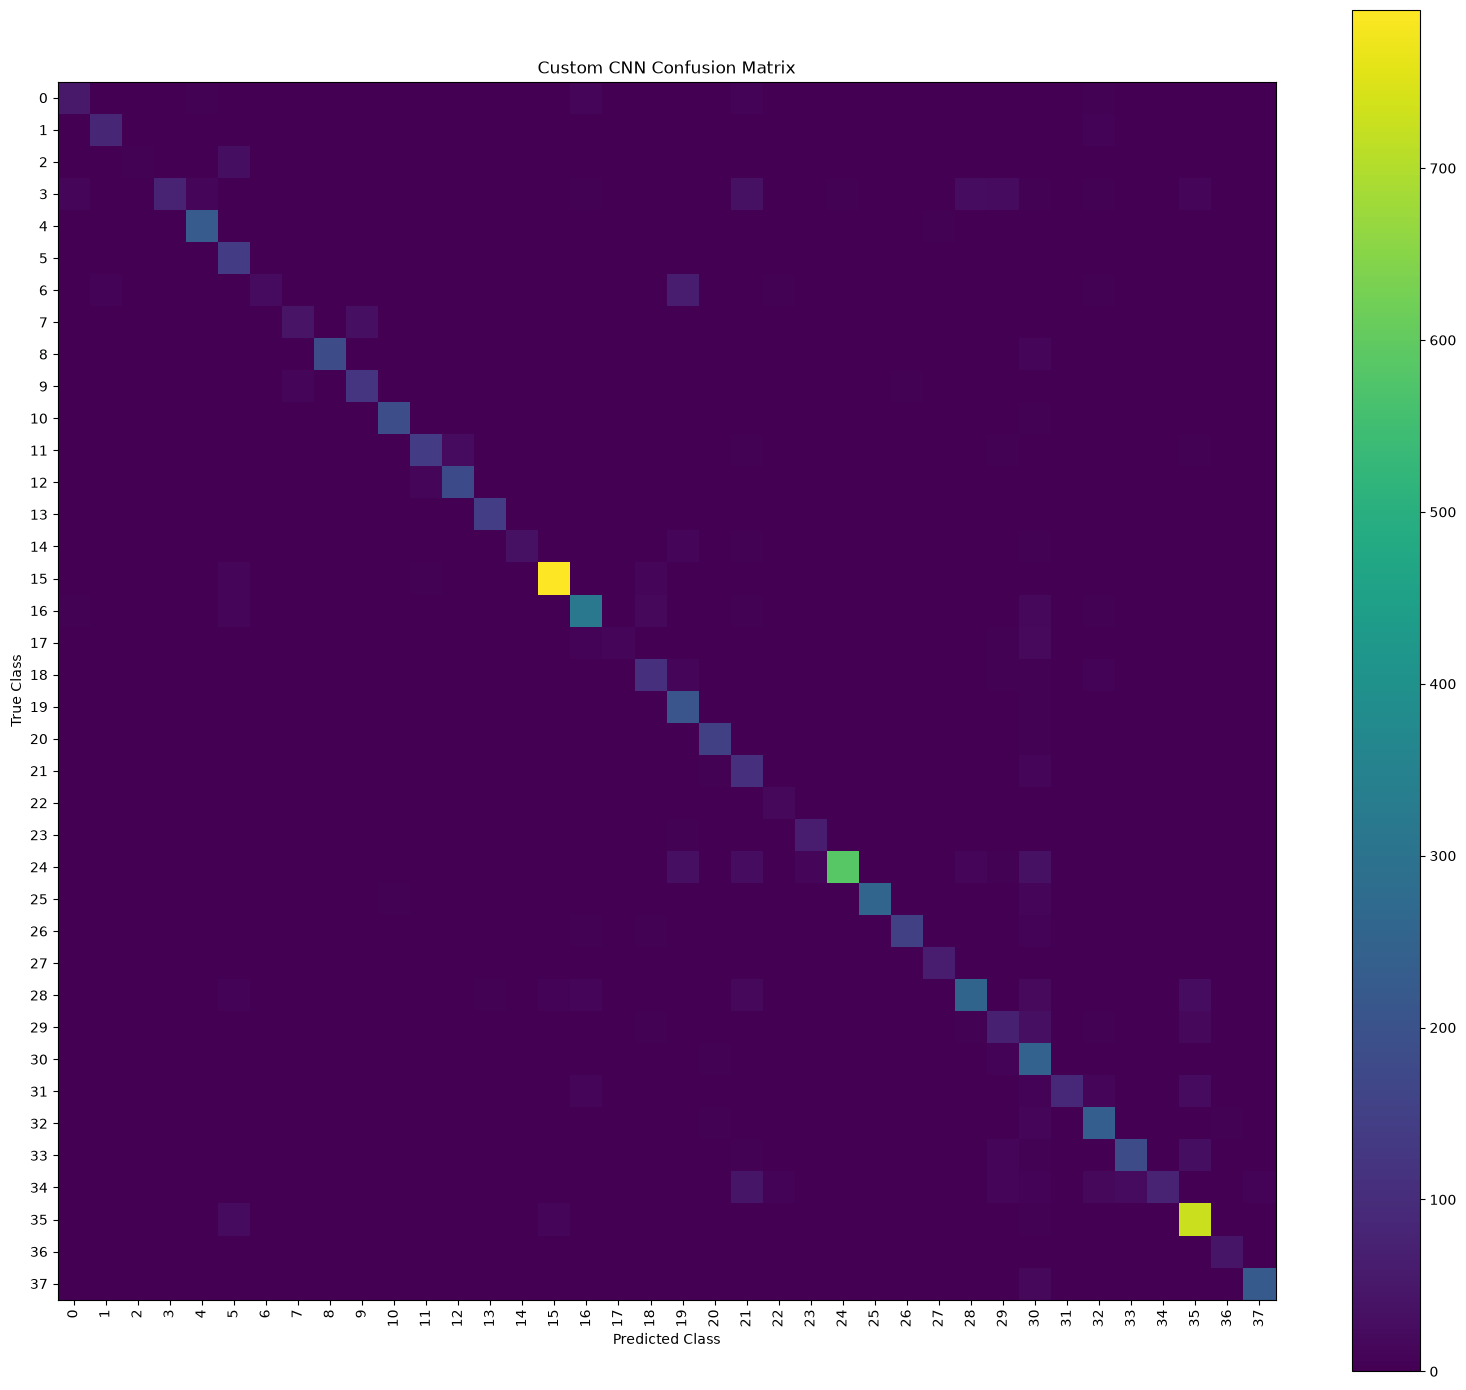

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))

plt.imshow(cm)
plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    range(len(class_names)),
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    range(len(class_names))
)

plt.tight_layout()
plt.show()

In [15]:
import os

os.makedirs("../models", exist_ok=True)

model.save("../models/custom_cnn_final.keras")

print("Custom CNN saved successfully!")

Custom CNN saved successfully!
